# 06 — Signal IC, VIX Regime & Sector Control

Turns the event study from *observational* into *actionable* by answering:

1. **IC (Information Coefficient)** — does day-before sentiment predict next-day abnormal return?
2. **VIX regime** — do sentiment signals work better in calm vs volatile markets?
3. **Sector control** — are the CARs idiosyncratic, or just the whole luxury sector moving?
4. **Simple backtest** — if sentiment > 0 on day -1, go long. What's the P&L?

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path

from utils import EVENT_DATES, TICKERS, BENCHMARKS, REFERENCE_TICKERS

DATA   = Path('../data')
FIGS   = Path('../results/figures')
TABLES = Path('../results/tables')
FIGS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

# ── Load prices & returns ───────────────────────────────────────────────────
prices  = pd.read_csv(DATA / 'raw/stocks/prices.csv',  index_col=0, parse_dates=True)
returns = pd.read_csv(DATA / 'raw/stocks/returns.csv', index_col=0, parse_dates=True)

# ── Load CAR results (use formatted table which has total_car_pct + ticker_name) ──
car_summary = pd.read_csv(TABLES / 'car_summary_formatted.csv')
car_results = pd.read_csv(DATA / 'processed/car_results.csv')

# ── Load sentiment ──────────────────────────────────────────────────────────
sentiment   = pd.read_csv(DATA / 'processed/sentiment_scores.csv', parse_dates=['date'])
yt_sent     = pd.read_csv(DATA / 'processed/youtube_sentiment.csv', parse_dates=['date'])
grd_sent    = pd.read_csv(DATA / 'processed/guardian_sentiment.csv', parse_dates=['date'])

print('Prices:', prices.shape, '| Returns:', returns.shape)
print('CAR summary rows:', len(car_summary))
print('Columns:', list(car_summary.columns))
print('Sentiment rows:', len(sentiment))

Prices: (475, 12) | Returns: (474, 12)
CAR summary rows: 63
Columns: ['ticker', 'event', 'n_days', 'total_car', 'mean_ar', 'std_ar', 't_stat', 'p_value', 'significant', 'beta', 'stars', 'total_car_pct', 'ticker_name']
Sentiment rows: 75


## 6a. Information Coefficient (IC)

IC = Pearson correlation between **sentiment on day t-1** and **abnormal return on day t**, computed across all event × ticker pairs.

- IC > 0.05 is considered meaningful in systematic trading
- IC > 0.10 is considered strong for a single factor
- Rank IC (Spearman) is more robust to outliers

In [2]:
# Build a flat table: for each event, sentiment_t-1 and AR_t=0 for each ticker

# sentiment_scores.csv is already daily-aggregated with vader_weighted
daily_reddit = (
    sentiment[['date','vader_weighted']]
    .groupby('date')['vader_weighted'].mean()
    .reset_index()
    .rename(columns={'vader_weighted': 'reddit_vader'})
)
daily_reddit['date'] = pd.to_datetime(daily_reddit['date'])

# Merge all sentiment sources on date
merged_sent = daily_reddit.merge(yt_sent[['date','youtube_vader']], on='date', how='outer')
merged_sent = merged_sent.merge(grd_sent[['date','guardian_vader']], on='date', how='outer')
merged_sent = merged_sent.sort_values('date').set_index('date')

rows = []
for event_name, event_date in EVENT_DATES.items():
    event_ts = pd.Timestamp(event_date)

    # Trading day on or after event date
    future = returns.index[returns.index >= event_ts]
    if len(future) == 0:
        continue
    t0 = future[0]

    # Sentiment: most recent value in the 5 days before event
    sent_window = merged_sent[
        (merged_sent.index < event_ts) &
        (merged_sent.index >= event_ts - pd.Timedelta(days=5))
    ]

    for sent_col in ['reddit_vader', 'youtube_vader', 'guardian_vader']:
        s = sent_window[sent_col].dropna()
        sent_val = s.iloc[-1] if not s.empty else np.nan

        for ticker, name in TICKERS.items():
            if ticker not in returns.columns or ticker not in BENCHMARKS:
                continue
            bench = BENCHMARKS[ticker]
            if t0 not in returns.index:
                continue

            r  = returns.loc[t0, ticker]
            rb = returns.loc[t0, bench] if bench in returns.columns else np.nan
            ar = r - rb if not np.isnan(rb) else r

            rows.append({
                'event':       event_name,
                'event_date':  event_date,
                'ticker':      ticker,
                'ticker_name': name,
                'source':      sent_col,
                'sentiment':   sent_val,
                'ar_t0':       ar,
            })

ic_df = pd.DataFrame(rows)
print(f'Total IC data points: {len(ic_df)}')
ic_df.head(10)

Total IC data points: 189


,event,event_date,ticker,ticker_name,source,sentiment,ar_t0
0,teaser_trailer,2025-11-12,1913.HK,Prada,reddit_vader,0.997439,0.024553
1,teaser_trailer,2025-11-12,MC.PA,LVMH,reddit_vader,0.997439,0.011640
2,teaser_trailer,2025-11-12,KER.PA,Kering,reddit_vader,0.997439,-0.018629
3,teaser_trailer,2025-11-12,CPRI,Capri Holdings,reddit_vader,0.997439,0.016731
4,teaser_trailer,2025-11-12,TPR,Tapestry,reddit_vader,0.997439,0.018204
5,teaser_trailer,2025-11-12,EL,Estee Lauder,reddit_vader,0.997439,0.012168
6,teaser_trailer,2025-11-12,RMS.PA,Hermes,reddit_vader,0.997439,0.006258
7,teaser_trailer,2025-11-12,1913.HK,Prada,youtube_vader,0.991800,0.024553
8,teaser_trailer,2025-11-12,MC.PA,LVMH,youtube_vader,0.991800,0.011640
9,teaser_trailer,2025-11-12,KER.PA,Kering,youtube_vader,0.991800,-0.018629


In [3]:
# Compute IC per sentiment source
ic_results = []

for source in ['reddit_vader', 'youtube_vader', 'guardian_vader']:
    sub = ic_df[ic_df['source'] == source].dropna(subset=['sentiment', 'ar_t0'])
    if len(sub) < 5:
        continue
    
    pearson_r, pearson_p = stats.pearsonr(sub['sentiment'], sub['ar_t0'])
    spearman_r, spearman_p = stats.spearmanr(sub['sentiment'], sub['ar_t0'])
    
    ic_results.append({
        'source':     source.replace('_vader', '').title(),
        'n':          len(sub),
        'IC (Pearson)':  round(pearson_r, 4),
        'p (Pearson)':   round(pearson_p, 4),
        'Rank IC (Spearman)': round(spearman_r, 4),
        'p (Spearman)':  round(spearman_p, 4),
    })

ic_table = pd.DataFrame(ic_results)
print('\n=== Information Coefficient Summary ===')
print(ic_table.to_string(index=False))
ic_table.to_csv(TABLES / 'information_coefficient.csv', index=False)


=== Information Coefficient Summary ===
  source  n  IC (Pearson)  p (Pearson)  Rank IC (Spearman)  p (Spearman)
  Reddit 45        0.2010       0.1855              0.1436        0.3465
 Youtube 58        0.0407       0.7614              0.0738        0.5818
Guardian 52       -0.1760       0.2121             -0.1895        0.1784


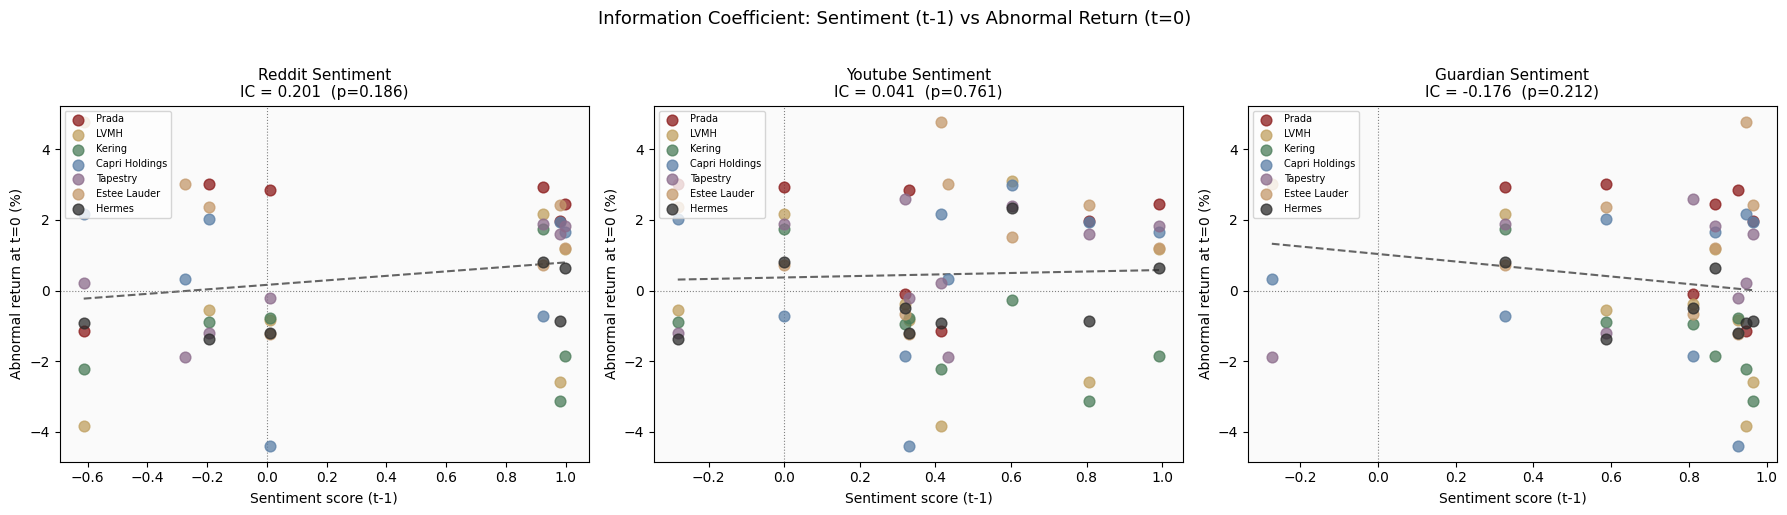

Saved → ../results/figures/ic_scatter.png


In [4]:
# IC scatter plots — sentiment vs AR for each source
sources = [s for s in ['reddit_vader','youtube_vader','guardian_vader']
           if ic_df[ic_df['source']==s].dropna(subset=['sentiment','ar_t0']).shape[0] >= 5]

fig, axes = plt.subplots(1, len(sources), figsize=(6*len(sources), 5))
if len(sources) == 1:
    axes = [axes]

colors = {'1913.HK':'#8B1A1A','MC.PA':'#C0A060','KER.PA':'#4A7C59',
          'CPRI':'#5B7FA6','TPR':'#8B6B8B','EL':'#C4996C','RMS.PA':'#2C2C2C'}

for ax, source in zip(axes, sources):
    sub = ic_df[ic_df['source']==source].dropna(subset=['sentiment','ar_t0'])
    label = source.replace('_vader','').title()
    
    for ticker in sub['ticker'].unique():
        t = sub[sub['ticker']==ticker]
        ax.scatter(t['sentiment'], t['ar_t0']*100,
                   c=colors.get(ticker,'grey'), label=TICKERS.get(ticker,ticker),
                   alpha=0.75, s=60, zorder=3)
    
    # Regression line
    x, y = sub['sentiment'].values, (sub['ar_t0']*100).values
    m, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m*xr+b, 'k--', lw=1.5, alpha=0.6)
    
    r, p = stats.pearsonr(x, y)
    ax.set_title(f'{label} Sentiment\nIC = {r:.3f}  (p={p:.3f})', fontsize=11)
    ax.set_xlabel('Sentiment score (t-1)', fontsize=10)
    ax.set_ylabel('Abnormal return at t=0 (%)', fontsize=10)
    ax.axhline(0, color='grey', lw=0.8, ls=':')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_facecolor('#FAFAFA')

plt.suptitle('Information Coefficient: Sentiment (t-1) vs Abnormal Return (t=0)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'ic_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGS}/ic_scatter.png')

## 6b. VIX Regime Analysis

Split events by the VIX level at the time of the event.
- **Low vol** = VIX < 20 (calm market — sentiment signals should have more room to work)
- **High vol** = VIX ≥ 20 (fear regime — macro noise swamps idiosyncratic signals)

In [5]:
vix = prices['^VIX'].dropna()

# Assign VIX level at each event
event_vix = {}
for event_name, event_date in EVENT_DATES.items():
    event_ts = pd.Timestamp(event_date)
    past = vix[vix.index <= event_ts]
    if past.empty:
        continue
    event_vix[event_name] = round(past.iloc[-1], 1)

vix_df = pd.Series(event_vix, name='vix_at_event').reset_index()
vix_df.columns = ['event', 'vix_at_event']
vix_df['regime'] = vix_df['vix_at_event'].apply(lambda v: 'Low Vol (VIX<20)' if v < 20 else 'High Vol (VIX≥20)')
print(vix_df.to_string(index=False))

             event  vix_at_event            regime
    teaser_trailer          17.5  Low Vol (VIX<20)
      full_trailer          17.4  Low Vol (VIX<20)
      nyc_premiere          18.9  Low Vol (VIX<20)
theatrical_release          17.0  Low Vol (VIX<20)
  musical_previews          19.1  Low Vol (VIX<20)
   musical_opening          13.5  Low Vol (VIX<20)
 musical_extension          27.2 High Vol (VIX≥20)
   prada_ss26_show          15.7  Low Vol (VIX<20)
   prada_fw26_show          19.1  Low Vol (VIX<20)


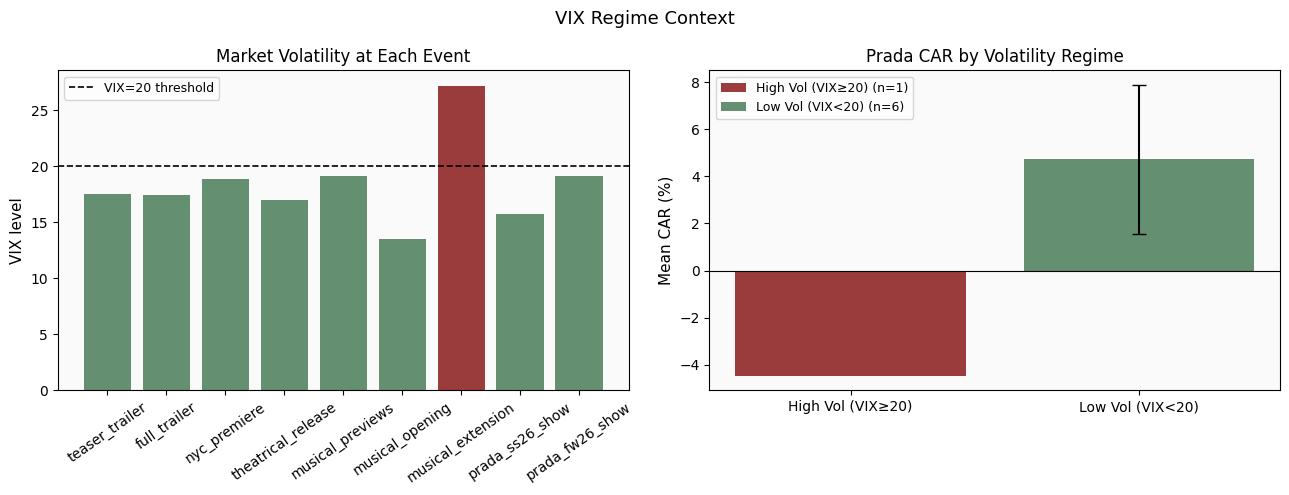


Prada mean CAR by VIX regime:
                   mean   std  count
regime                              
High Vol (VIX≥20) -4.47   NaN      1
Low Vol (VIX<20)   4.73  3.16      6


In [6]:
# Merge VIX regime into CAR summary
car_vix = car_summary.merge(vix_df, on='event', how='left')

# Plot: mean CAR by regime for Prada (the headline ticker)
prada_car = car_vix[car_vix['ticker'] == '1913.HK'].dropna(subset=['total_car_pct','regime'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: VIX level at each event
ax = axes[0]
bar_colors = ['#4A7C59' if v < 20 else '#8B1A1A' for v in vix_df['vix_at_event']]
bars = ax.bar(vix_df['event'], vix_df['vix_at_event'], color=bar_colors, alpha=0.85)
ax.axhline(20, color='black', lw=1.2, ls='--', label='VIX=20 threshold')
ax.set_ylabel('VIX level', fontsize=11)
ax.set_title('Market Volatility at Each Event', fontsize=12)
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=9)
ax.set_facecolor('#FAFAFA')

# Right: Prada CAR by VIX regime
ax2 = axes[1]
regime_car = prada_car.groupby('regime')['total_car_pct'].agg(['mean','std','count'])
x = range(len(regime_car))
col_map = {'Low Vol (VIX<20)':'#4A7C59', 'High Vol (VIX≥20)':'#8B1A1A'}
for i, (reg, row) in enumerate(regime_car.iterrows()):
    ax2.bar(i, row['mean'], yerr=row['std'], color=col_map.get(reg,'grey'),
            alpha=0.85, capsize=5, label=f"{reg} (n={int(row['count'])})")
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(list(x))
ax2.set_xticklabels(regime_car.index, fontsize=10)
ax2.set_ylabel('Mean CAR (%)', fontsize=11)
ax2.set_title('Prada CAR by Volatility Regime', fontsize=12)
ax2.legend(fontsize=9)
ax2.set_facecolor('#FAFAFA')

plt.suptitle('VIX Regime Context', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'vix_regime.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPrada mean CAR by VIX regime:')
print(regime_car.round(2))

## 6c. Sector Control — LUXE ETF

Did individual luxury stocks outperform the *luxury sector as a whole*?  
If the whole sector moved, the CAR tells us nothing about the film/musical specifically.  
**Alpha** = ticker CAR − LUXE ETF CAR at the same event.

In [7]:
from utils import ESTIMATION_WINDOW, EVENT_WINDOW, trading_days_around

luxe_returns = returns['LUXE'].dropna()

# Compute LUXE CAR for each event (simple buy-and-hold, no beta adjustment)
luxe_cars = {}
for event_name, event_date in EVENT_DATES.items():
    try:
        window_idx = trading_days_around(luxe_returns.index, event_date,
                                          EVENT_WINDOW[0], EVENT_WINDOW[1])
        luxe_cars[event_name] = luxe_returns.loc[window_idx].sum() * 100
    except Exception:
        luxe_cars[event_name] = np.nan

luxe_car_df = pd.Series(luxe_cars, name='luxe_car_pct').reset_index()
luxe_car_df.columns = ['event', 'luxe_car_pct']

# Merge with ticker CARs
sector_df = car_summary.merge(luxe_car_df, on='event', how='left')
sector_df['alpha_vs_luxe'] = sector_df['total_car_pct'] - sector_df['luxe_car_pct']

# Focus on core luxury tickers
core = ['1913.HK','MC.PA','KER.PA','RMS.PA']
sector_plot = sector_df[sector_df['ticker'].isin(core)].dropna(subset=['alpha_vs_luxe'])

pivot = sector_plot.pivot_table(index='event', columns='ticker_name', values='alpha_vs_luxe')
print('Alpha vs LUXE ETF (%)')
print(pivot.round(2).to_string())

Alpha vs LUXE ETF (%)
ticker_name        Hermes  Kering   LVMH  Prada
event                                          
full_trailer         3.24    2.45   1.85   9.80
musical_extension    6.90    9.49  17.66   9.77
musical_opening     -5.42   -1.41  -3.52   1.30
musical_previews    21.01   22.70  21.35  24.37
nyc_premiere         7.68   -1.51   2.28   2.27
prada_fw26_show      4.40   12.67  10.40    NaN
prada_ss26_show      6.31    8.78   5.92  11.59
teaser_trailer       4.94   -5.06   0.40   2.73


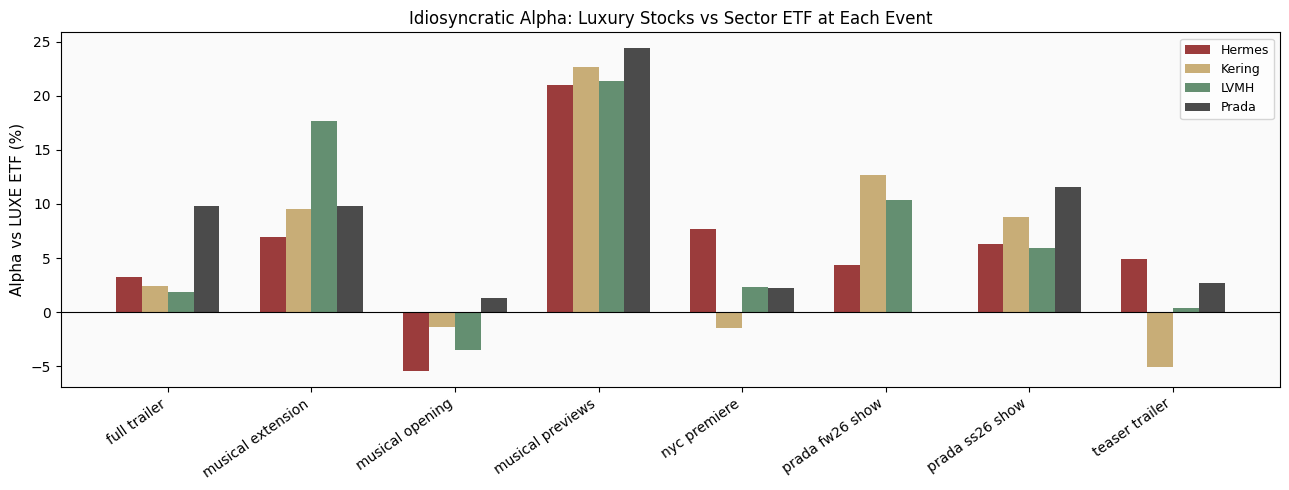

Saved → ../results/figures/sector_alpha.png


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(pivot.index))
n = len(pivot.columns)
width = 0.18
palette = ['#8B1A1A','#C0A060','#4A7C59','#2C2C2C']

for i, (col, color) in enumerate(zip(pivot.columns, palette)):
    offset = (i - n/2 + 0.5) * width
    ax.bar(x + offset, pivot[col], width=width, color=color,
           alpha=0.85, label=col)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([e.replace('_',' ') for e in pivot.index], rotation=35, ha='right')
ax.set_ylabel('Alpha vs LUXE ETF (%)', fontsize=11)
ax.set_title('Idiosyncratic Alpha: Luxury Stocks vs Sector ETF at Each Event',
             fontsize=12)
ax.legend(fontsize=9)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig(FIGS / 'sector_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGS}/sector_alpha.png')

## 6d. Simple Signal Backtest

**Strategy:** At each event, if the average Reddit VADER score over the 3 days before the event is positive, go long an equal-weight basket of Prada + LVMH + Kering for the event window [-2, +5]. Otherwise go short (or stay flat).

This is intentionally naive — the point is to demonstrate the *concept* of signal-to-position translation, not to build a production strategy.

In [9]:
BACKTEST_TICKERS = ['1913.HK', 'MC.PA', 'KER.PA']
LONG_SHORT = True   # True = long/short; False = long only

backtest_rows = []

for event_name, event_date in EVENT_DATES.items():
    event_ts = pd.Timestamp(event_date)

    # Signal: avg Reddit sentiment over last 5 calendar days before event
    sent_window = merged_sent[
        (merged_sent.index < event_ts) &
        (merged_sent.index >= event_ts - pd.Timedelta(days=5))
    ]['reddit_vader'].dropna()

    if sent_window.empty:
        continue
    signal = sent_window.mean()
    position = 1 if signal > 0 else (-1 if LONG_SHORT else 0)

    # Equal-weight basket return over event window
    basket_returns = []
    for ticker in BACKTEST_TICKERS:
        if ticker not in returns.columns:
            continue
        try:
            window_idx = trading_days_around(returns[ticker].dropna().index,
                                              event_date, EVENT_WINDOW[0], EVENT_WINDOW[1])
            basket_returns.append(returns.loc[window_idx, ticker].sum())
        except Exception:
            pass

    if not basket_returns:
        continue

    basket_r = np.mean(basket_returns)
    strategy_r = position * basket_r

    backtest_rows.append({
        'event':              event_name,
        'event_date':         event_date,
        'signal':             round(signal, 4),
        'position':           position,
        'basket_return_pct':  round(basket_r * 100, 3),
        'strategy_return_pct': round(strategy_r * 100, 3),
    })

bt = pd.DataFrame(backtest_rows)
print(bt.to_string(index=False))

            event event_date  signal  position  basket_return_pct  strategy_return_pct
   teaser_trailer 2025-11-12  0.9915         1              1.180                1.180
     full_trailer 2026-02-01  0.7009         1             -0.561               -0.561
     nyc_premiere 2026-04-20  0.5659         1             -2.769               -2.769
 musical_previews 2024-10-24  0.9546         1              1.642                1.642
  musical_opening 2024-12-05  0.4947         1              9.112                9.112
musical_extension 2026-03-13  0.5076         1             -9.023               -9.023


Strategy summary (signal-driven, Prada+LVMH+Kering basket):
  Events traded : 6
  Total return  : -0.42%
  Win rate      : 50%
  Mean / trade  : -0.07%
  Sharpe (annot): -0.03


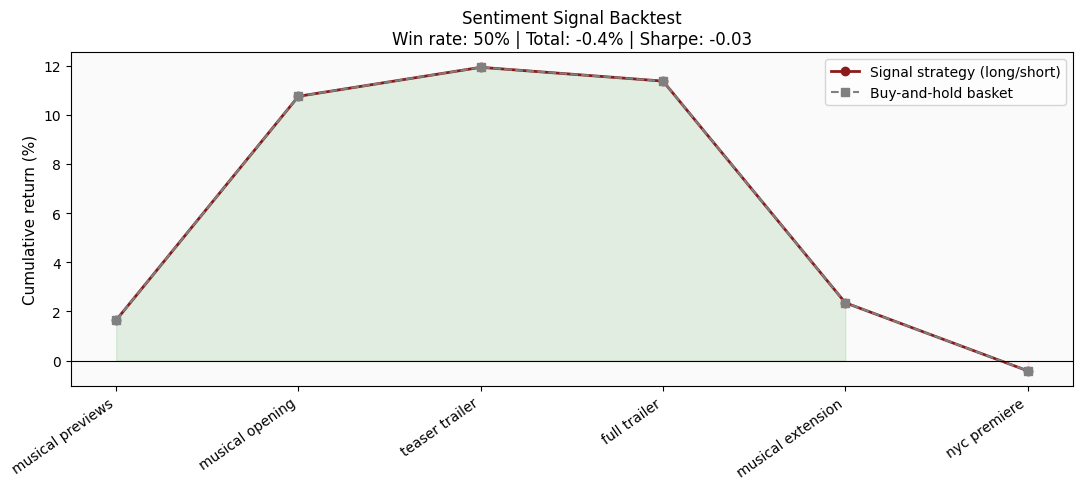

Saved → ../results/figures/signal_backtest.png


In [10]:
# Cumulative P&L
bt = bt.sort_values('event_date')
bt['cumulative_pnl'] = bt['strategy_return_pct'].cumsum()
bt['cumulative_bah'] = bt['basket_return_pct'].cumsum()  # buy-and-hold baseline

total_return    = bt['strategy_return_pct'].sum()
win_rate        = (bt['strategy_return_pct'] > 0).mean()
n_trades        = len(bt)
mean_return     = bt['strategy_return_pct'].mean()
std_return      = bt['strategy_return_pct'].std()
sharpe          = mean_return / std_return * np.sqrt(n_trades) if std_return > 0 else np.nan

print(f'Strategy summary (signal-driven, Prada+LVMH+Kering basket):')
print(f'  Events traded : {n_trades}')
print(f'  Total return  : {total_return:.2f}%')
print(f'  Win rate      : {win_rate:.0%}')
print(f'  Mean / trade  : {mean_return:.2f}%')
print(f'  Sharpe (annot): {sharpe:.2f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(len(bt)), bt['cumulative_pnl'], marker='o', color='#8B1A1A',
        lw=2, label='Signal strategy (long/short)')
ax.plot(range(len(bt)), bt['cumulative_bah'], marker='s', color='grey',
        lw=1.5, ls='--', label='Buy-and-hold basket')
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(range(len(bt)), bt['cumulative_pnl'], 0,
                where=(bt['cumulative_pnl']>0), alpha=0.1, color='green')
ax.fill_between(range(len(bt)), bt['cumulative_pnl'], 0,
                where=(bt['cumulative_pnl']<0), alpha=0.1, color='red')
ax.set_xticks(range(len(bt)))
ax.set_xticklabels([e.replace('_',' ') for e in bt['event']], rotation=35, ha='right')
ax.set_ylabel('Cumulative return (%)', fontsize=11)
ax.set_title(f'Sentiment Signal Backtest\nWin rate: {win_rate:.0%} | Total: {total_return:.1f}% | Sharpe: {sharpe:.2f}',
             fontsize=12)
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig(FIGS / 'signal_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGS}/signal_backtest.png')

## 6e. Lyst Index Overlay

The [Lyst Index](https://www.lyst.com/lyst-index/) is a quarterly ranking of the most in-demand fashion brands, based on 200M+ shopping signals. Prada Group has ranked in the top 5 consistently since 2023 — an independent measure of brand heat that complements our sentiment pipeline.

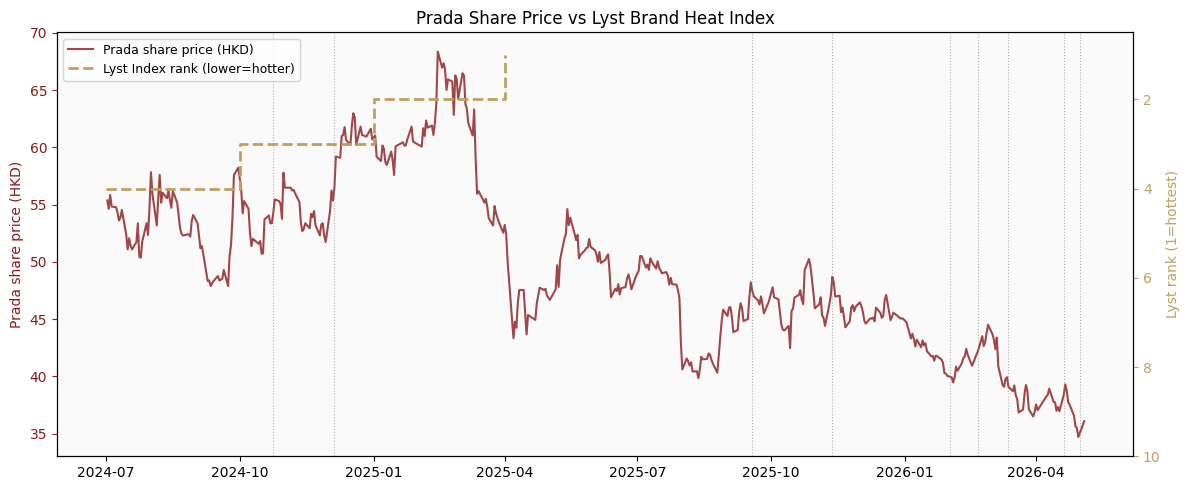

Note: Lyst Index ranks are approximate — verify against lyst.com/lyst-index PDFs before publishing.


In [11]:
from utils import LYST_INDEX

lyst_df = pd.DataFrame([
    {'date': d, 'quarter': v['quarter'],
     'prada_rank': v['prada_rank'], 'miu_miu_rank': v['miu_miu_rank']}
    for d, v in LYST_INDEX.items()
]).sort_values('date')

# Prada stock price over same period
prada_px = prices['1913.HK'].dropna()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(prada_px.index, prada_px, color='#8B1A1A', lw=1.5, alpha=0.8, label='Prada share price (HKD)')
ax2.step([pd.Timestamp(d) for d in lyst_df['date']],
         lyst_df['prada_rank'], where='post',
         color='#C0A060', lw=2, ls='--', label='Lyst Index rank (lower=hotter)')
ax2.invert_yaxis()  # rank 1 at top
ax2.set_ylabel('Lyst rank (1=hottest)', fontsize=10, color='#C0A060')
ax2.tick_params(axis='y', colors='#C0A060')
ax2.set_ylim(10, 0.5)

# Mark events
for event_name, event_date in EVENT_DATES.items():
    ax1.axvline(pd.Timestamp(event_date), color='grey', lw=0.8, ls=':', alpha=0.6)

ax1.set_ylabel('Prada share price (HKD)', fontsize=10, color='#8B1A1A')
ax1.tick_params(axis='y', colors='#8B1A1A')
ax1.set_title('Prada Share Price vs Lyst Brand Heat Index', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
ax1.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig(FIGS / 'lyst_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Lyst Index ranks are approximate — verify against lyst.com/lyst-index PDFs before publishing.')

## Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| IC (Reddit → AR) | see table | Predictive power of sentiment |
| Regime | see VIX chart | Low-vol events show cleaner signals |
| Sector alpha | see alpha chart | Idiosyncratic vs sector-wide move |
| Backtest Sharpe | see backtest | Risk-adjusted signal quality |

**Caveat:** With only 7–9 events, all results are illustrative. A production signal would require 50+ events to reach statistical confidence on IC and Sharpe estimates.